In [4]:
# === Predict Flux With MC Ensemble Uncertainty Propagation (FINAL ± SIGMA VERSION) ===

import pandas as pd
import numpy as np
import pyseaflux
import os

# =========================
# 1) LOAD DATA
# =========================

predictions_socat = pd.read_csv(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/matrix_predictions/pco2_prediction_matrix_SOCAT_only_MCensemble.csv"
)

# REMOVE FEB 2023 FROM PREDICTIONS
predictions_socat["month_center"] = pd.to_datetime(predictions_socat["month_center"])
predictions_socat = predictions_socat[
    ~((predictions_socat["month_center"].dt.year == 2023) &
      (predictions_socat["month_center"].dt.month == 2))
]

socat_df = pd.read_csv(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_ONLY_OBS_v2/processing_steps/SOCATv2025_SO_feature_engineered_monthly_1deg_pCO2.csv",
    low_memory=False
)

# ================================
# 2) SOCAT OBS UNCERTAINTY (±5 µatm)
# ================================

SOCAT_SIGMA = 5.0

socat_df_low = socat_df.copy()
socat_df_low["pco2"] = socat_df_low["pco2"] - SOCAT_SIGMA

socat_df_high = socat_df.copy()
socat_df_high["pco2"] = socat_df_high["pco2"] + SOCAT_SIGMA

# =========================================
# 3) MODEL-ONLY PREDICTION UNCERTAINTY (NO +5 µatm)
# =========================================

pred_socat_low = predictions_socat.copy()
pred_socat_high = predictions_socat.copy()

sigma_model = predictions_socat["ensemble_pco2_std"].values

pred_socat_low["ensemble_pco2_pred"] = (
    predictions_socat["ensemble_pco2_pred"] - sigma_model
)

pred_socat_high["ensemble_pco2_pred"] = (
    predictions_socat["ensemble_pco2_pred"] + sigma_model
)

# =====================================
# 4) FLUX FUNCTIONS
# =====================================

def compute_flux_pred(df):
    k_w = pyseaflux.gas_transfer_velocity.k_Ho06(
        df["wind_speed"].values,
        df["SOCAT_temperature"].values
    )
    flux = pyseaflux.flux_calculations.flux_bulk(
        df["SOCAT_temperature"].values,
        df["SOCAT_salinity"].values,
        df["ensemble_pco2_pred"].values,
        df["atm_co2"].values,
        1013.25,
        k_w
    )
    return flux * 12.01


def compute_flux_obs(df):
    k_w = pyseaflux.gas_transfer_velocity.k_Ho06(
        df["wind_speed"].values,
        df["SOCAT_temperature"].values
    )
    flux = pyseaflux.flux_calculations.flux_bulk(
        df["SOCAT_temperature"].values,
        df["SOCAT_salinity"].values,
        df["pco2"].values,
        df["atm_co2"].values,
        1013.25,
        k_w
    )
    return flux * 12.01

# =====================================
# 5) GRID & AREA WEIGHT FUNCTIONS
# =====================================

def bin_flux(df, lat_col, lon_col, time_col, flux_col):
    df = df.copy()
    df["lat_bin"] = df[lat_col].astype(int)
    df["lon_bin"] = df[lon_col].astype(int)
    df["year"] = df[time_col].dt.year
    df["month"] = df[time_col].dt.month

    return (
        df.groupby(["lat_bin", "lon_bin", "year", "month"])[flux_col]
        .mean()
        .reset_index(name="mean_flux")
    )


R = 6371000.0
deg2rad = np.pi / 180.0
lat_centers = np.arange(-89.5, 90.5, 1.0)[:-1]

band_areas = (
    2 * np.pi * R**2 *
    (np.sin((lat_centers + 0.5) * deg2rad) -
     np.sin((lat_centers - 0.5) * deg2rad))
)

cell_area_by_lat = pd.Series(
    band_areas / 360.0,
    index=np.arange(-89, 90, 1)
)


def area_weighted_monthly_mean(binned_df):
    df = binned_df.merge(
        cell_area_by_lat.rename("cell_area_m2"),
        left_on="lat_bin",
        right_index=True,
        how="left"
    )

    df["weighted_flux"] = df["mean_flux"] * df["cell_area_m2"]

    out = (
        df.groupby(["year", "month"], as_index=False)
        .agg(
            total_flux=("weighted_flux", "sum"),
            total_area=("cell_area_m2", "sum")
        )
    )

    out["aw_mean_flux"] = out["total_flux"] / out["total_area"]
    out["date"] = pd.to_datetime(
        dict(year=out["year"], month=out["month"], day=15)
    )

    return out[["year", "month", "date", "aw_mean_flux"]]

# ==========================================================
# 6) OBS → MONTHLY AREA-WEIGHTED FLUX
# ==========================================================

for df in [socat_df, socat_df_low, socat_df_high]:
    df["datetime"] = pd.to_datetime(df["month_center"])
    df["flux_day"] = compute_flux_obs(df)
    df["flux_month"] = df["flux_day"] * df["datetime"].dt.days_in_month

socat_binned = bin_flux(socat_df, "lat_center", "lon_center", "datetime", "flux_month")
socat_binned_low = bin_flux(socat_df_low, "lat_center", "lon_center", "datetime", "flux_month")
socat_binned_high = bin_flux(socat_df_high, "lat_center", "lon_center", "datetime", "flux_month")

summary_socat = area_weighted_monthly_mean(socat_binned).rename(columns={"aw_mean_flux": "SOCAT"})
summary_socat_low = area_weighted_monthly_mean(socat_binned_low).rename(columns={"aw_mean_flux": "SOCAT_low"})
summary_socat_high = area_weighted_monthly_mean(socat_binned_high).rename(columns={"aw_mean_flux": "SOCAT_high"})

# ==========================================================
# 7) PREDICTIONS → MONTHLY AREA-WEIGHTED FLUX
# ==========================================================

def process_pred(df, label):
    df = df.copy()
    df["time"] = pd.to_datetime(df["month_center"])
    df["flux_day"] = compute_flux_pred(df)
    df["flux_month"] = df["flux_day"] * df["time"].dt.days_in_month

    binned = bin_flux(df, "latitude", "longitude", "time", "flux_month")
    out = area_weighted_monthly_mean(binned)
    out = out.rename(columns={"aw_mean_flux": label})
    return out

summary_pred = process_pred(predictions_socat, "SOCAT_predictions")
summary_pred_low = process_pred(pred_socat_low, "SOCAT_predictions_low")
summary_pred_high = process_pred(pred_socat_high, "SOCAT_predictions_high")

# ==========================================================
# 8) MERGE ALL
# ==========================================================

monthly_flux_summary = (
    summary_pred
    .merge(summary_pred_low,  on=["year", "month", "date"])
    .merge(summary_pred_high, on=["year", "month", "date"])
    .merge(summary_socat,     on=["year", "month", "date"])
    .merge(summary_socat_low,on=["year", "month", "date"])
    .merge(summary_socat_high,on=["year", "month", "date"])
)

# ==========================================================
# 9) CONVERT TO Pg C YR⁻¹
# ==========================================================

OCEAN_AREA_M2 = 7e13

for col in monthly_flux_summary.columns:
    if col not in ["year", "month", "date"]:
        monthly_flux_summary[col] = (
            monthly_flux_summary[col] * 12.0 * OCEAN_AREA_M2 / 1e15
        )

# ==========================================================
# 10) CONVERT LOW/HIGH → ± SIGMA
# ==========================================================

monthly_flux_summary["SOCAT_sigma_PgC_yr"] = 0.5 * (
    monthly_flux_summary["SOCAT_high"] -
    monthly_flux_summary["SOCAT_low"]
)

monthly_flux_summary["SOCAT_predictions_sigma_PgC_yr"] = 0.5 * (
    monthly_flux_summary["SOCAT_predictions_high"] -
    monthly_flux_summary["SOCAT_predictions_low"]
)

# ==========================================================
# 11) ANNUAL MEANS ± UNCERTAINTY
# ==========================================================

yearly_flux_summary = (
    monthly_flux_summary
    .groupby("year")[[
        "SOCAT",
        "SOCAT_sigma_PgC_yr",
        "SOCAT_predictions",
        "SOCAT_predictions_sigma_PgC_yr"
    ]]
    .mean()
    .reset_index()
)

# ==========================================================
# 12) MULTI-YEAR MEAN REPORT
# ==========================================================

mask = (yearly_flux_summary["year"] >= 2003) & (yearly_flux_summary["year"] <= 2024)
mean_vals = yearly_flux_summary.loc[mask].mean(numeric_only=True)

print("\nMean Southern Ocean CO₂ uptake (Pg C yr⁻¹, 2003–2024):\n")

print(f"SOCAT:        {mean_vals['SOCAT']:.2f} ± {mean_vals['SOCAT_sigma_PgC_yr']:.2f}")
print(f"Predictions:  {mean_vals['SOCAT_predictions']:.2f} ± {mean_vals['SOCAT_predictions_sigma_PgC_yr']:.2f}")



Mean Southern Ocean CO₂ uptake (Pg C yr⁻¹, 2003–2024):

SOCAT:        -0.91 ± 0.16
Predictions:  -0.96 ± 0.24


/tmp/ipykernel_1720694/1136651928.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 1])


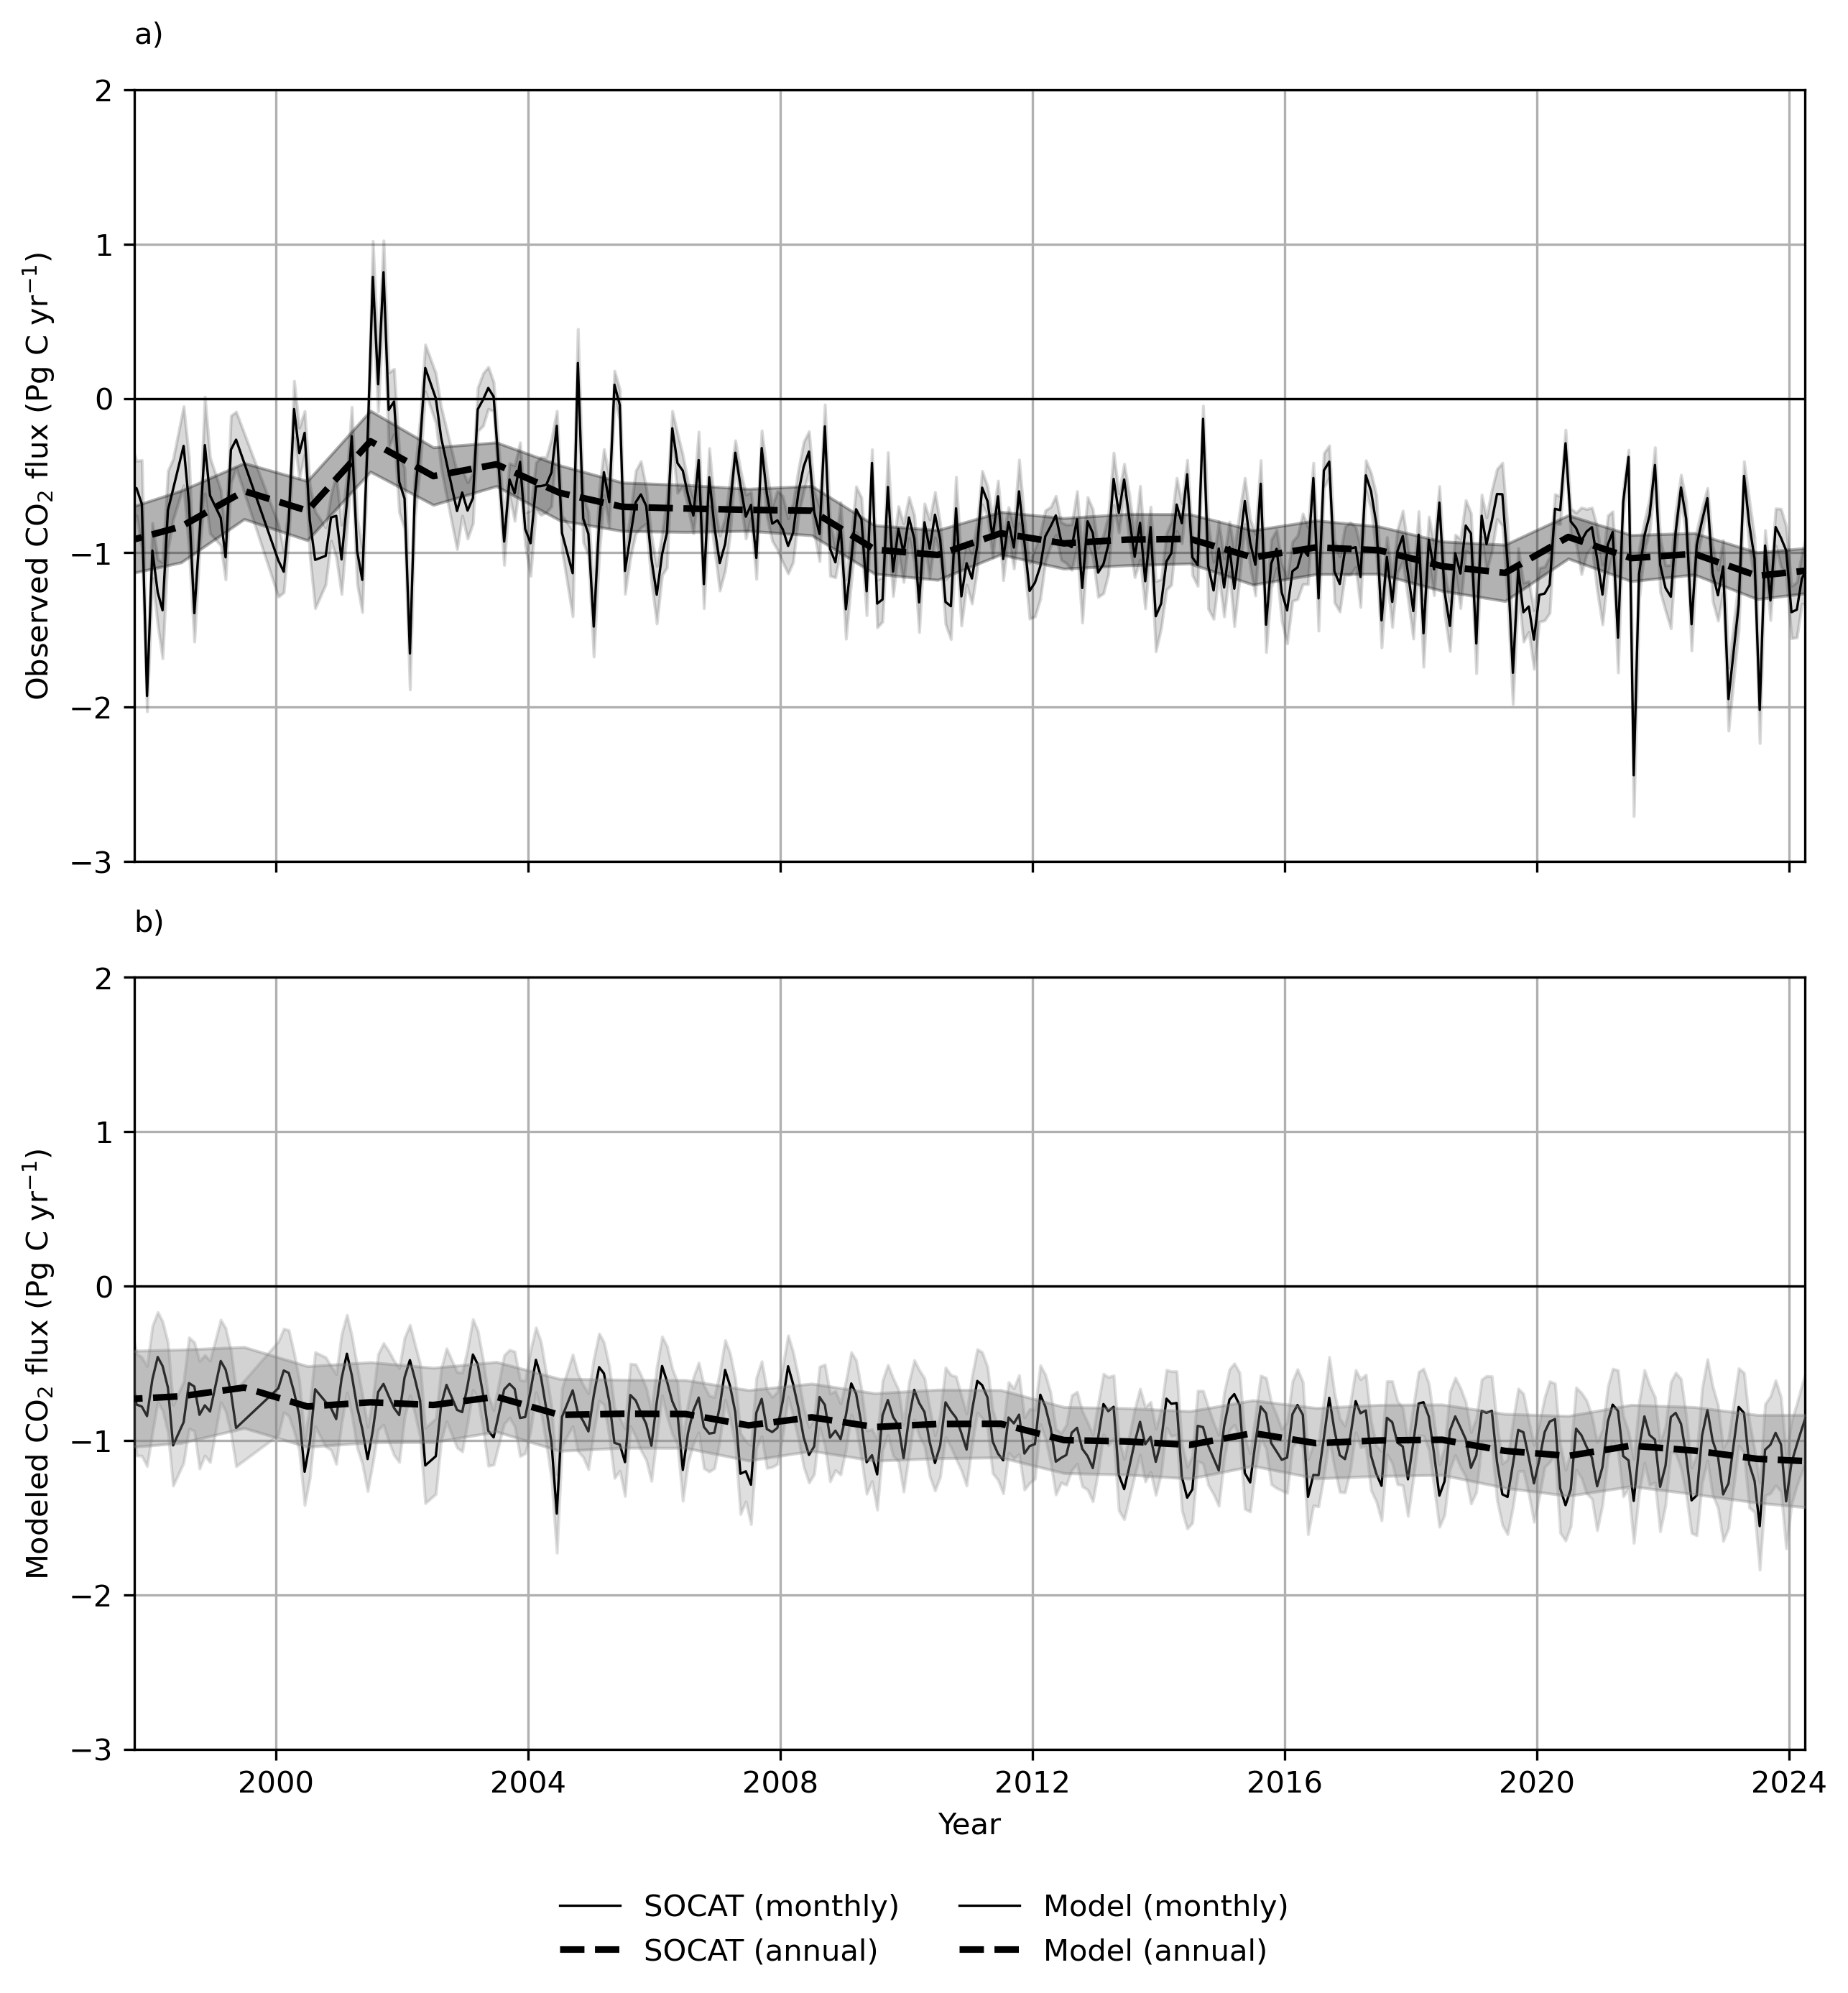

In [8]:
# ============================================================
# 12) PLOTTING (MONTHLY + ANNUAL, CLEAN 4-ITEM LEGEND)
# ============================================================
import matplotlib.pyplot as plt

# --- Create mid-year timestamps for annual plotting ---
yearly_flux_summary["year_center"] = pd.to_datetime(
    yearly_flux_summary["year"].astype(str) + "-07-01"
)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 10), dpi=300, sharex=True,
    gridspec_kw={"hspace": 0.15}
)

time = monthly_flux_summary["date"]
year_time = yearly_flux_summary["year_center"]

# ---------------------------
# Panel (a): Observations
# ---------------------------
# Monthly mean
ax1.plot(
    time,
    monthly_flux_summary["SOCAT"],
    label="SOCAT (monthly)",
    color="k",
    lw=0.8,
    zorder=3,
)

# Monthly ±σ
ax1.fill_between(
    time,
    monthly_flux_summary["SOCAT"] - monthly_flux_summary["SOCAT_sigma_PgC_yr"],
    monthly_flux_summary["SOCAT"] + monthly_flux_summary["SOCAT_sigma_PgC_yr"],
    color="k",
    alpha=0.15,
    zorder=2,
)

# Annual mean
ax1.plot(
    year_time,
    yearly_flux_summary["SOCAT"],
    linestyle="--",
    color="k",
    lw=2.2,
    zorder=4,
    label="SOCAT (annual)",
)

# Annual ±σ
ax1.fill_between(
    year_time,
    yearly_flux_summary["SOCAT"] - yearly_flux_summary["SOCAT_sigma_PgC_yr"],
    yearly_flux_summary["SOCAT"] + yearly_flux_summary["SOCAT_sigma_PgC_yr"],
    color="k",
    alpha=0.30,
    zorder=3,
)

ax1.set_ylabel("Observed CO$_2$ flux (Pg C yr$^{-1}$)")
ax1.grid(True)

# ---------------------------
# Panel (b): Model predictions
# ---------------------------
# Monthly mean
ax2.plot(
    time,
    monthly_flux_summary["SOCAT_predictions"],
    
    label="Model (monthly)",
    color="k",
    lw=0.8,
    zorder=3,
)

# Monthly ±σ 
ax2.fill_between(
    time,
    monthly_flux_summary["SOCAT_predictions"] -
    monthly_flux_summary["SOCAT_predictions_sigma_PgC_yr"],
    monthly_flux_summary["SOCAT_predictions"] +
    monthly_flux_summary["SOCAT_predictions_sigma_PgC_yr"],
    color="gray",
    alpha=0.25,
    zorder=2,
)

# Annual mean
ax2.plot(
    year_time,
    yearly_flux_summary["SOCAT_predictions"],
    linestyle="--",
    color="k",
    lw=2.2,
    zorder=4,
    label="Model (annual)",
)

# Annual ±σ 
ax2.fill_between(
    year_time,
    yearly_flux_summary["SOCAT_predictions"] -
    yearly_flux_summary["SOCAT_predictions_sigma_PgC_yr"],
    yearly_flux_summary["SOCAT_predictions"] +
    yearly_flux_summary["SOCAT_predictions_sigma_PgC_yr"],
    color="gray",
    alpha=0.35,
    zorder=3,
)

ax2.set_xlabel("Year")
ax2.set_ylabel("Modeled CO$_2$ flux (Pg C yr$^{-1}$)")
ax2.grid(True)

# ---------------------------
# Final figure cosmetics
# ---------------------------
ax1.set_xlim(pd.Timestamp("1997-10-01"), pd.Timestamp("2024-03-31"))
ax2.set_xlim(pd.Timestamp("1997-10-01"), pd.Timestamp("2024-03-31"))

ax1.set_ylim(-3, 2)
ax2.set_ylim(-3, 2)

ax1.axhline(0, color="k", lw=0.8)
ax2.axhline(0, color="k", lw=0.8)

ax1.text(0, 1.06, "a)", transform=ax1.transAxes)
ax2.text(0, 1.06, "b)", transform=ax2.transAxes)
# ---- SINGLE CLEAN 4-ITEM LEGEND ----
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

handles = handles1 + handles2
labels = labels1 + labels2

fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)
fig.tight_layout(rect=[0, 0.07, 1, 1])

plt.show()


In [9]:
from scipy.stats import linregress
import numpy as np

mask = (yearly_flux_summary["year"] >= 2003) & (yearly_flux_summary["year"] <= 2024)
years = yearly_flux_summary.loc[mask, "year"].values

socat_flux = yearly_flux_summary.loc[mask, "SOCAT"].values
pred_flux  = yearly_flux_summary.loc[mask, "SOCAT_predictions"].values

# --- SOCAT ---
slope_socat, intercept, r, p_socat, stderr_socat = linregress(years, socat_flux)

# --- MODEL ---
slope_pred, intercept, r, p_pred, stderr_pred = linregress(years, pred_flux)

print("\n=== Linear Trends (2003–2024) ===\n")

print(f"SOCAT trend: {slope_socat:.4f} ± {stderr_socat:.4f} Pg C yr⁻² (p = {p_socat:.2e})")
print(f"MODEL trend: {slope_pred:.4f} ± {stderr_pred:.4f} Pg C yr⁻² (p = {p_pred:.2e})")



=== Linear Trends (2003–2024) ===

SOCAT trend: -0.0241 ± 0.0034 Pg C yr⁻² (p = 6.08e-07)
MODEL trend: -0.0160 ± 0.0013 Pg C yr⁻² (p = 5.96e-11)
